### Before start, load inference environments, gpu, cuda, ...

In [1]:
from envs import actenv_jupyter, change_exp_dir, make_gpu_mem_reporter
actenv_jupyter(cuda_version="12.9", gcc_version="11", clear_cache=False)

[actenv_jupyter] CUDA_HOME=/usr/local/cuda-12.9
[actenv_jupyter] TORCH_CUDA_ARCH_LIST=8.0
[actenv_jupyter] CXX=/usr/bin/g++-11 | CC=/usr/bin/gcc-11
[actenv_jupyter] Ready.


{'CUDA_HOME': '/usr/local/cuda-12.9',
 'TORCH_CUDA_ARCH_LIST': '8.0',
 'CC': '/usr/bin/gcc-11',
 'CXX': '/usr/bin/g++-11',
 'CUDAHOSTCXX': '/usr/bin/g++-11',
 'CXXFLAGS': '-std=c++17',
 'PATH_head': '/usr/local/cuda-12.9/bin:/home/ids/yuhe/anaconda3/envs/styleGANenv/bin:/home/ids/yuhe/.vscode-server/cli/servers/Stable-94e8ae2b28cb5cc932b86e1070569c4463565c37/server/bin/remote-cli',
 'LD_LIBRARY_PATH_head': '/usr/local/cuda-12.9/lib64:/usr/local/cuda-12.9/lib64:$LD_LIBRARY_PATH',
 'TORCH_CUDA_VERBOSE_BUILD': '1',
 'MAX_JOBS': '1'}

### Set experiment dir and models' paths

In [25]:
import torch
import os
import yaml

root_dir = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN"
sfe_root = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS"
medminist_path = '/home/ids/yuhe/Projects/CA_with_GAN/2_data/medical_datasets'
med_path = '/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging'

Paths_models = {
        "stylegan_weights": '/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pretrained_models/stylegan2/stylegan2_medical_images/brats_rosinality.pt',
        "pSp_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp/results/brats_ht_Ros_resume/checkpoints/iteration_20000.pt",
        "pSp_cs_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/bratsHT/checkpoints/iteration_30000.pt",  
        }

change_exp_dir(sfe_root)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


from runners.model_funcs import load_pSp_cs_models
pSp_net, cs_mlp_net, opts = load_pSp_cs_models(pSp_cs_path=Paths_models["pSp_cs_path"], 
        pSp_path=Paths_models["pSp_path"], device=device, eval_models=True)   

# from torchvision.utils import save_image
from utils.common_utils import tensor2im, get_keys, visualize_batch_grid
from inference_ipynb.inference_funcs import recon_by_latent_w, configure_datasets_v2, get_random_seeds
# import shutil
from tqdm import tqdm
import random
# import torch.nn.functional as F
def inference(pSp_net, cs_mlp_net, opts, test_bg_dataloader, test_t_dataloader, idx):
    with torch.no_grad():
        for batch_idx, (batch_bg, batch_t) in tqdm(enumerate(zip(test_bg_dataloader, test_t_dataloader)), total=len(test_bg_dataloader)):

                X = batch_bg.to(device).float()
                Y = batch_t.to(device).float()

                rec_pSp_X, w_X_pSp = pSp_net.forward(X, return_latents=True)
                rec_pSp_Y, w_Y_pSp = pSp_net.forward(Y, return_latents=True) 

                latent_X_c, latent_X_s = cs_mlp_net(w_X_pSp, zero_out_silent=opts.zero_out_silent_bg)
                latent_Y_c, latent_Y_s = cs_mlp_net(w_Y_pSp, zero_out_silent=opts.zero_out_silent_t) 

                rec_X = pSp_net.forward(latent_X_c, input_code=True, randomize_noise=True, recon_modle=True)
                rec_Y = pSp_net.forward(latent_Y_c + latent_Y_s, input_code=True, randomize_noise=True, recon_modle=True)        
                swap_cs_X = pSp_net.forward(latent_X_c + latent_Y_s, input_code=True, randomize_noise=True, recon_modle=True)
                swap_cs_Y = pSp_net.forward(latent_Y_c, input_code=True, randomize_noise=True, recon_modle=True)    
                
                break
        # -----------------------------
        # select index (fixed or random)
        # -----------------------------
        if idx is None:
            idx = random.randint(0, X.size(0) - 1) 

        # prepare rows
        row1 = torch.stack([X[idx], rec_pSp_X[idx], rec_X[idx], swap_cs_X[idx]], dim=0)
        row2 = torch.stack([Y[idx], rec_pSp_Y[idx], rec_Y[idx], swap_cs_Y[idx]], dim=0)

        columns = [torch.stack([row1[i], row2[i]], dim=0) for i in range(len(row1))]
        %matplotlib inline
        visualize_batch_grid(
        image_batches=columns,
        titles=["Input", "Recon w", "Recon cs", "Swap cs"],
        save_path=None
        )

cwd: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS
Using device: cuda
Loading pSp from checkpoint: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp/results/brats_ht_Ros_resume/checkpoints/iteration_20000.pt
Loading cs mlp from path: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/bratsHT/checkpoints/iteration_30000.pt


Random seed: 3728
Loading dataset
Using dataset: brats_ht_new


Loading pSp from checkpoint: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp/results/brats_ht_Ros_resume/checkpoints/iteration_20000.pt
Loading cs mlp from path: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/bratsHT_new/checkpoints/iteration_20000.pt


  0%|          | 0/521 [00:00<?, ?it/s]


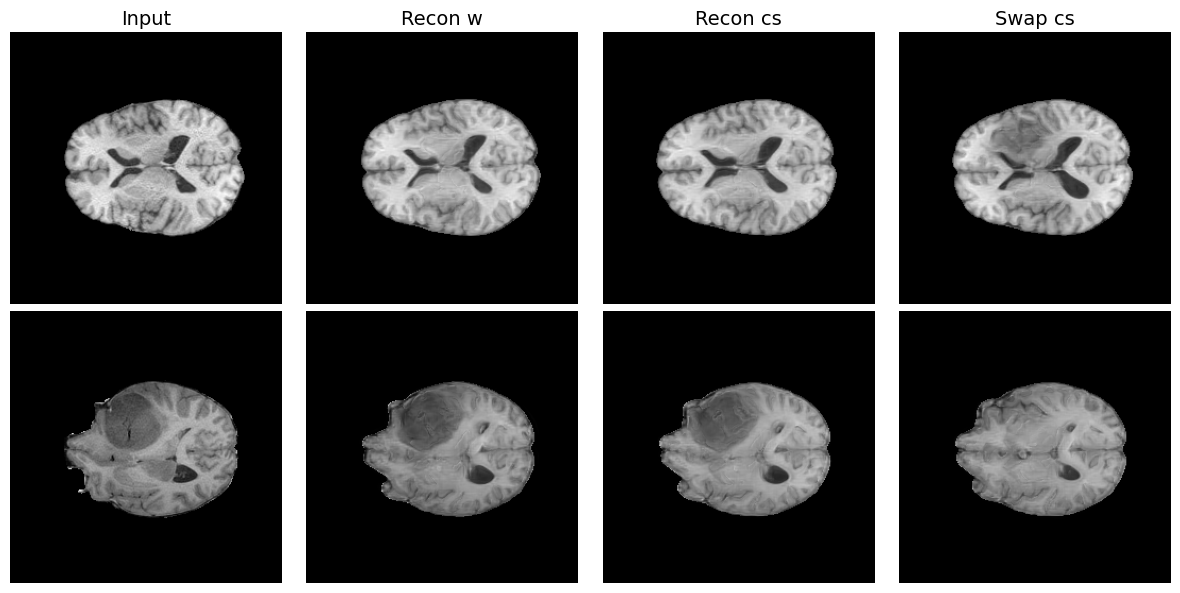

In [77]:
seed = get_random_seeds()
# seed = 1215
ds_name = 'brats_ht_new'
test_bg_dataloader, test_t_dataloader = configure_datasets_v2(batch_size=4, workers=4, test_images=True, seed=seed, shuffle=True, ds_name = ds_name)

pSp_cs_path = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/bratsHT_new/checkpoints/iteration_20000.pt"

pSp_net, cs_mlp_net, opts = load_pSp_cs_models(pSp_cs_path=pSp_cs_path, 
        pSp_path=Paths_models["pSp_path"], device=device, eval_models=True)   

inference(pSp_net, cs_mlp_net, opts, test_bg_dataloader, test_t_dataloader, idx = 1)


Random seed: 10232
Loading dataset
Using dataset: brats_ht
Loading pSp from checkpoint: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp/results/brats_ht_Ros_resume/checkpoints/iteration_20000.pt
Loading cs mlp from path: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/bratsHT_new/checkpoints/iteration_20000.pt


  0%|          | 0/726 [00:00<?, ?it/s]


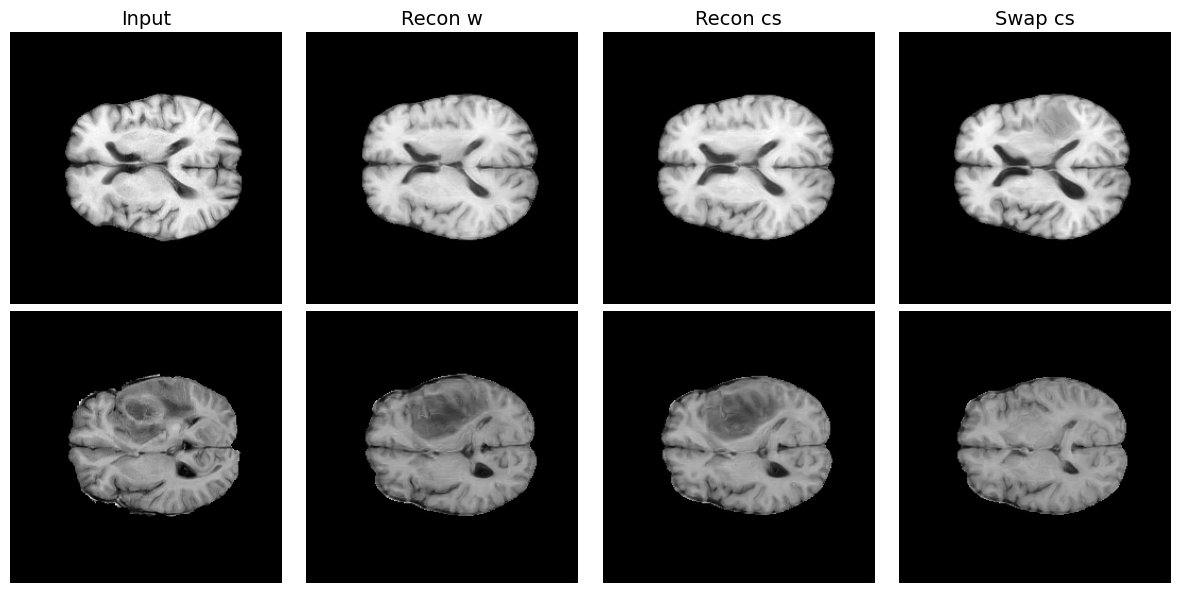

In [99]:
seed = get_random_seeds()
# seed = 14360
ds_name = 'brats_ht'
test_bg_dataloader, test_t_dataloader = configure_datasets_v2(batch_size=4, workers=4, test_images=True, seed=seed, shuffle=True, ds_name = ds_name)

pSp_cs_path = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/bratsHT_new/checkpoints/iteration_20000.pt"

pSp_net, cs_mlp_net, opts = load_pSp_cs_models(pSp_cs_path=pSp_cs_path, 
        pSp_path=Paths_models["pSp_path"], device=device, eval_models=True)   

inference(pSp_net, cs_mlp_net, opts, test_bg_dataloader, test_t_dataloader, idx = 1)


In [11]:
2000/8

250.0